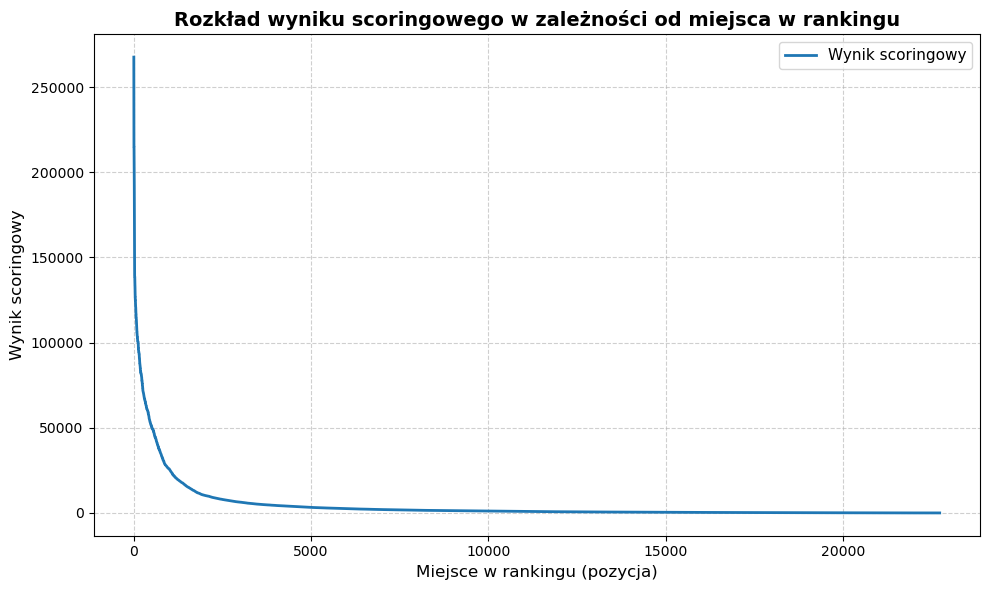

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Wczytanie danych
df = pd.read_csv("../data/candidate_locations_ze_scoringiem.csv", low_memory=False)

# 2. Czyszczenie wartości liczbowych
df["wynik_scoringowy"] = pd.to_numeric(
    df["wynik_scoringowy"].astype(str).str.replace(',', '.'), 
    errors='coerce'
)

# 3. Sortowanie malejąco i wyznaczenie pozycji w rankingu
df_sorted = df.sort_values(by="wynik_scoringowy", ascending=False).reset_index(drop=True)
df_sorted["miejsce_w_rankingu"] = df_sorted.index + 1

# 4. Generowanie wykresu liniowego
plt.figure(figsize=(10, 6))
plt.plot(
    df_sorted["miejsce_w_rankingu"], 
    df_sorted["wynik_scoringowy"], 
    color='#1f77b4', 
    linewidth=2, 
    label="Wynik scoringowy"
)

# 5. Formatowanie wykresu
plt.title("Rozkład wyniku scoringowego w zależności od miejsca w rankingu", fontsize=14, fontweight='bold')
plt.xlabel("Miejsce w rankingu (pozycja)", fontsize=12)
plt.ylabel("Wynik scoringowy", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

# 6. Zapis i wyświetlenie
plt.savefig("wykres_scoring_ranking.png", dpi=300)
plt.show()

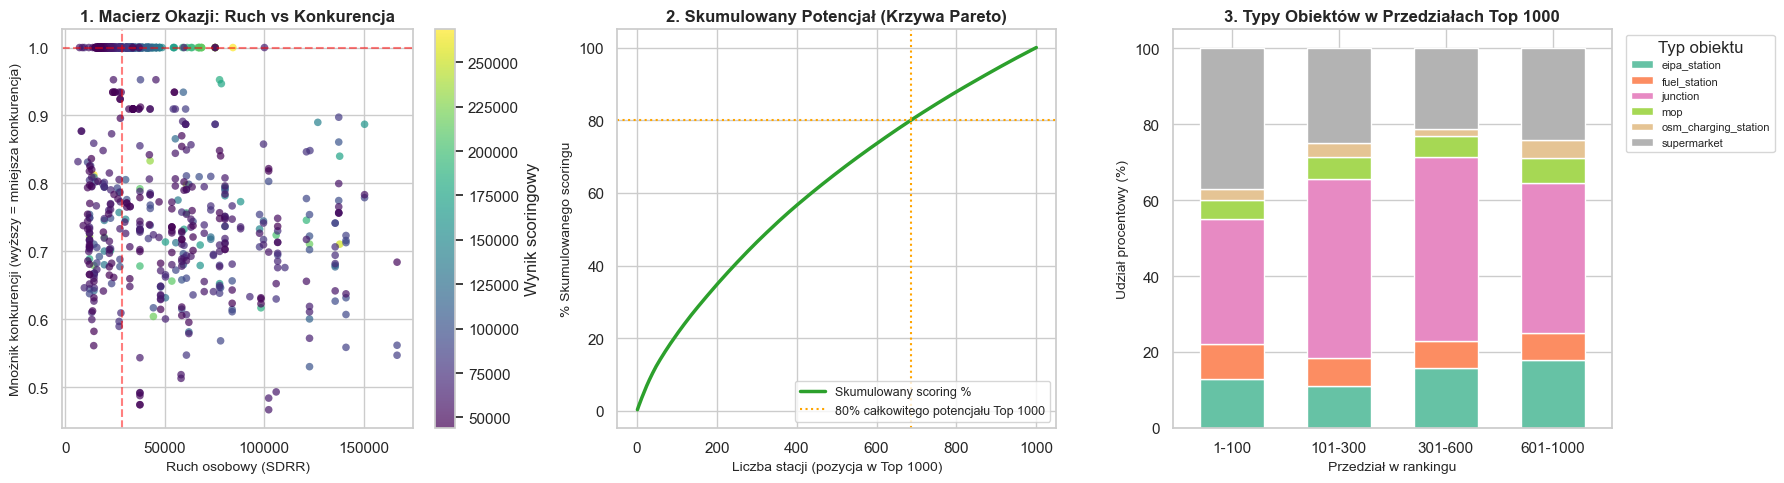

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Wczytanie i przygotowanie danych
df = pd.read_csv("../data/candidate_locations_ze_scoringiem.csv", low_memory=False)

# Czyszczenie kolumn liczbowych
num_cols = [
    "wynik_scoringowy",
    "traffic_primary_sam_osobowe",
    "konkurencja_korekta_mnoznik",
    "energia_kwh_rocznie_szacunek",
]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", "."), errors="coerce"
        ).fillna(0)

# Wydzielenie Top 1000
top1000 = df.sort_values(by="wynik_scoringowy", ascending=False).head(1000).copy()

# Konfiguracja stylu wykresów
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 5))

# -----------------------------------------------------------------------------
# WYKRES 1: Macierz Okazji (Ruch vs Konkurencja w Top 1000)
# -----------------------------------------------------------------------------
ax1 = fig.add_subplot(1, 3, 1)
scatter = ax1.scatter(
    top1000["traffic_primary_sam_osobowe"],
    top1000["konkurencja_korekta_mnoznik"],
    c=top1000["wynik_scoringowy"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="none",
    s=30,
)
fig.colorbar(scatter, ax=ax1, label="Wynik scoringowy")

# Linie podziału na ćwiartki (mediany)
ax1.axvline(
    top1000["traffic_primary_sam_osobowe"].median(),
    color="red",
    linestyle="--",
    alpha=0.5,
)
ax1.axhline(
    top1000["konkurencja_korekta_mnoznik"].median(),
    color="red",
    linestyle="--",
    alpha=0.5,
)

ax1.set_title(
    "1. Macierz Okazji: Ruch vs Konkurencja", fontsize=12, fontweight="bold"
)
ax1.set_xlabel("Ruch osobowy (SDRR)", fontsize=10)
ax1.set_ylabel("Mnożnik konkurencji (wyższy = mniejsza konkurencja)", fontsize=10)

# -----------------------------------------------------------------------------
# WYKRES 2: Skumulowany Potencjał (Krzywa Pareto dla Top 1000)
# -----------------------------------------------------------------------------
ax2 = fig.add_subplot(1, 3, 2)
top1000["cumsum_score"] = top1000["wynik_scoringowy"].cumsum()
top1000["cumsum_pct"] = (
    top1000["cumsum_score"] / top1000["wynik_scoringowy"].sum()
) * 100
top1000["pozycja"] = np.arange(1, len(top1000) + 1)

ax2.plot(
    top1000["pozycja"],
    top1000["cumsum_pct"],
    color="#2ca02c",
    linewidth=2.5,
    label="Skumulowany scoring %",
)
ax2.axhline(80, color="orange", linestyle=":", label="80% całkowitego potencjału Top 1000")

# Oznaczenie punktu 80%
p80_idx = (top1000["cumsum_pct"] >= 80).idxmax()
p80_pos = top1000.loc[p80_idx, "pozycja"]
ax2.axvline(p80_pos, color="orange", linestyle=":")

ax2.set_title(
    "2. Skumulowany Potencjał (Krzywa Pareto)", fontsize=12, fontweight="bold"
)
ax2.set_xlabel("Liczba stacji (pozycja w Top 1000)", fontsize=10)
ax2.set_ylabel("% Skumulowanego scoringu", fontsize=10)
ax2.legend(loc="lower right", fontsize=9)

# -----------------------------------------------------------------------------
# WYKRES 3: Struktura Typów Obiektów w Grupach Rankingu
# -----------------------------------------------------------------------------
ax3 = fig.add_subplot(1, 3, 3)

# Podział Top 1000 na 4 grupy (przedziały)
top1000["grupa_rankingu"] = pd.cut(
    top1000["pozycja"],
    bins=[0, 100, 300, 600, 1000],
    labels=["1-100", "101-300", "301-600", "601-1000"],
)

struktura = (
    pd.crosstab(
        top1000["grupa_rankingu"], top1000["source_layer"], normalize="index"
    )
    * 100
)
struktura.plot(kind="bar", stacked=True, ax=ax3, colormap="Set2", width=0.6)

ax3.set_title(
    "3. Typy Obiektów w Przedziałach Top 1000", fontsize=12, fontweight="bold"
)
ax3.set_xlabel("Przedział w rankingu", fontsize=10)
ax3.set_ylabel("Udział procentowy (%)", fontsize=10)
ax3.legend(title="Typ obiektu", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax3.tick_params(axis="x", rotation=0)

# Zapis zestawu wykresów
plt.tight_layout()
plt.savefig("analiza_top1000_1_2_3.png", dpi=300, bbox_inches="tight")
plt.show()

In [1]:
# wczytanie danych + male czyszczenie kolumn liczbowych (czasem GUS/GDDKiA
# zapisuja liczby z przecinkiem zamiast kropki, wiec trzeba to ogarnac)
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

print("Wczytuje dane...")
df = pd.read_csv("../data/candidate_locations_ze_scoringiem.csv", low_memory=False)

num_cols = [
    "energia_kwh_rocznie_szacunek", "pewnosc_danych_mnoznik", "afir_luka_mnoznik",
    "ruch_mnoznik", "konkurencja_korekta_mnoznik", "dostawcze_mnoznik",
    "wynik_scoringowy", "dystans_do_hubu_afir_km", "nearest_dk_lekkie_ciezarowe",
    "traffic_primary_sam_osobowe", "existing_eipa_power_kw_active_1km",
    "existing_eipa_power_kw_active_2km", "powiat_ludnosc", "powiat_liczba_ev_razem"
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)

kor = df["segment"] == "korytarzowa"
dest = df["segment"] == "docelowa"

print(f"Zaladowano {len(df):,} lokalizacji, {len(df.columns)} kolumn.")


Wczytuje dane...
Zaladowano 22,734 lokalizacji, 104 kolumn.


In [2]:
# sprawdzam czy wagi z AHP sa spojne, i jak poszczegolne zmienne
# koreluja z koncowym wynikiem (Spearman, bo zaleznosci raczej nie sa liniowe)
print("\n=== Korelacje ze zmiennymi rynkowymi ===")

print("\nWagi AHP: Ruch 46.7%, Konkurencja 27.7%, AFIR 16.0%, Popyt docelowy 9.5%")
print("Wspolczynnik niespojnosci CR = 0.0116 (< 0.10, wiec ok)")

vars_to_corr = [
    ("energia_kwh_rocznie_szacunek", "Szacowany popyt roczny (kWh)"),
    ("traffic_primary_sam_osobowe", "Ruch osobowy (GPR)"),
    ("nearest_dk_lekkie_ciezarowe", "Ruch dostawczy (DK)"),
    ("powiat_liczba_ev_razem", "Flota EV w powiecie"),
]

corr_results = []
for col, label in vars_to_corr:
    if col in df.columns:
        corr, pval = spearmanr(df[col], df["wynik_scoringowy"])
        corr_results.append({"Zmienna": label, "Korelacja Spearmana": round(corr, 3),
                              "p-value": "< 0.001" if pval < 0.001 else round(pval, 3)})

print(pd.DataFrame(corr_results).to_string(index=False))



=== Korelacje ze zmiennymi rynkowymi ===

Wagi AHP: Ruch 46.7%, Konkurencja 27.7%, AFIR 16.0%, Popyt docelowy 9.5%
Wspolczynnik niespojnosci CR = 0.0116 (< 0.10, wiec ok)
                     Zmienna  Korelacja Spearmana p-value
Szacowany popyt roczny (kWh)                0.932 < 0.001
          Ruch osobowy (GPR)                0.409 < 0.001
         Ruch dostawczy (DK)                0.345 < 0.001
         Flota EV w powiecie                0.465 < 0.001


In [3]:
# szukam podejrzanych przypadkow - niski ruch ale wysoki wynik, to by
# sugerowalo ze model "wymyslil sobie" wysoki wynik znikad
print("\n=== Anomalie i aktywnosc mnoznikow ===")

low_traffic = df["traffic_primary_sam_osobowe"] < df["traffic_primary_sam_osobowe"].quantile(0.10)
high_score = df["wynik_scoringowy"] > df["wynik_scoringowy"].quantile(0.90)
anomalie = df[low_traffic & high_score]

print(f"Lokalizacje z niskim ruchem (<10 percentyl) i wysokim wynikiem (>90 percentyl): "
      f"{len(anomalie)} / {len(df)} ({len(anomalie)/len(df):.2%})")

# ile razy poszczegolne mnozniki faktycznie cos zmieniaja (czyli != 1.0)
mnozniki = ["pewnosc_danych_mnoznik", "afir_luka_mnoznik", "ruch_mnoznik",
            "dostawcze_mnoznik", "konkurencja_korekta_mnoznik"]
stats = df[mnozniki].describe().T[["mean", "std", "min", "50%", "max"]]
stats["aktywnosc_%"] = [(df[m] != 1.0).mean() * 100 for m in mnozniki]

print("\nProfil mnoznikow:")
print(stats.round(3).to_string())



=== Anomalie i aktywnosc mnoznikow ===
Lokalizacje z niskim ruchem (<10 percentyl) i wysokim wynikiem (>90 percentyl): 11 / 22734 (0.05%)

Profil mnoznikow:
                              mean    std    min    50%    max  aktywnosc_%
pewnosc_danych_mnoznik       0.997  0.017  0.750  1.000  1.000        2.529
afir_luka_mnoznik            1.001  0.010  1.000  1.000  1.196        2.186
ruch_mnoznik                 1.000  0.080  0.850  1.000  1.150       86.188
dostawcze_mnoznik            1.003  0.022  0.920  1.000  1.120       13.812
konkurencja_korekta_mnoznik  0.500  0.359  0.071  0.322  1.000       67.964


In [4]:
# analiza wrazliwosci - co sie stanie z rankingiem, jesli pokrecic
# poszczegolnymi wagami. Jesli TOP 20 sie kompletnie rozjezdza przy
# drobnej zmianie, to zly znak (model za bardzo zalezy od jednego parametru)
print("\n=== Analiza wrazliwosci (jeden parametr na raz) ===")

top20 = df.nlargest(20, "wynik_scoringowy")["wynik_scoringowy"]
top1_val, top20_val = top20.iloc[0], top20.iloc[-1]
diff_pct = ((top1_val - top20_val) / top20_val) * 100

print(f"\nLider: {top1_val:,.2f} pkt, ostatni w top20: {top20_val:,.2f} pkt "
      f"(przewaga +{diff_pct:.1f}%)")

wyniki = []

def sprawdz(nazwa, opis, score_nowy):
    top20_orig = set(df.nlargest(20, "wynik_scoringowy").index)
    top20_new = set(df.assign(temp=score_nowy).nlargest(20, "temp").index)
    ov_20 = len(top20_orig & top20_new) / 20 * 100

    top100_orig = set(df.nlargest(100, "wynik_scoringowy").index)
    top100_new = set(df.assign(temp=score_nowy).nlargest(100, "temp").index)
    ov_100 = len(top100_orig & top100_new) / 100 * 100

    if ov_20 >= 90:
        ocena = "odporny"
    elif ov_20 >= 75:
        ocena = "srednio wrazliwy"
    else:
        ocena = "wrazliwy"

    wyniki.append({"Test": nazwa, "Co zmienione": opis, "TOP20 overlap": f"{ov_20:.1f}%",
                   "TOP100 overlap": f"{ov_100:.1f}%", "Ocena": ocena})

# cofam mnoznik do czystego "udzialu luki" i przeliczam z inna waga
czysty_afir = (df["afir_luka_mnoznik"] - 1.0) / 0.20
sprawdz("WAGA_AFIR = 0.10", "polowa obecnej premii", df["wynik_scoringowy"] / df["afir_luka_mnoznik"] * (1.0 + 0.10 * czysty_afir))
sprawdz("WAGA_AFIR = 0.40", "podwojona premia", df["wynik_scoringowy"] / df["afir_luka_mnoznik"] * (1.0 + 0.40 * czysty_afir))

dost_off = df["dostawcze_mnoznik"].copy()
dost_off.loc[kor] = 1.0
sprawdz("bez mnoznika dostawczego", "wylaczony modyfikator kurierow/vanow", df["wynik_scoringowy"] / df["dostawcze_mnoznik"] * dost_off)

sprawdz("bez kary za pewnosc danych", "traffic_confidence nie wplywa na wynik", df["wynik_scoringowy"] / df["pewnosc_danych_mnoznik"])

print("\nStabilnosc rankingu po zmianach:")
print(pd.DataFrame(wyniki).to_string(index=False))



=== Analiza wrazliwosci (jeden parametr na raz) ===

Lider: 267,577.07 pkt, ostatni w top20: 145,126.61 pkt (przewaga +84.4%)

Stabilnosc rankingu po zmianach:
                      Test                           Co zmienione TOP20 overlap TOP100 overlap   Ocena
          WAGA_AFIR = 0.10                  polowa obecnej premii        100.0%         100.0% odporny
          WAGA_AFIR = 0.40                       podwojona premia        100.0%         100.0% odporny
  bez mnoznika dostawczego   wylaczony modyfikator kurierow/vanow        100.0%          97.0% odporny
bez kary za pewnosc danych traffic_confidence nie wplywa na wynik        100.0%          94.0% odporny


In [5]:
# backtesting - gdzie w rankingu wypadaja stacje operatorow ktorzy juz
# realnie zainwestowali w Polsce. Jesli model ma sens, ich stacje powinny
# wypadac powyzej sredniej, nie gdzies w dole
print("\n=== Gdzie wypadaja znane stacje w rankingu ===")

operatorzy = {
    "Tesla": "Tesla Poland sp. z o.o.",
    "GreenWay": "GreenWay Polska Sp. z o.o.",  # UWAGA: nie "S.A.", inaczej 0 wynikow
    "ORLEN": "ORLEN S.A.",
}

wyniki_op = []
for short_name, full_name in operatorzy.items():
    stacje = df[(df["source_layer"] == "eipa_station") & (df["operator"] == full_name)]
    if len(stacje) > 0:
        wyniki_op.append({
            "Operator": short_name,
            "n": len(stacje),
            "Sredni percentyl": f"{stacje['ranking_scoringowy_procentyl'].mean():.1%}",
            "Mediana": f"{stacje['ranking_scoringowy_procentyl'].median():.1%}",
        })
    else:
        print(f"UWAGA: 0 dopasowan dla {short_name} ('{full_name}') - sprawdz nazwe operatora")

print(pd.DataFrame(wyniki_op).to_string(index=False))



=== Gdzie wypadaja znane stacje w rankingu ===
Operator   n Sredni percentyl Mediana
   Tesla  18            36.8%   28.7%
GreenWay 879            46.7%   44.4%
   ORLEN 191            45.1%   43.0%


# Podsumowanie walidacji modelu scoringowego

## Spójność wag i korelacje

Wagi z AHP wychodzą spójne (CR = 0,0116, więc poniżej progu 0,10 - dobrze). Korelacja Spearmana popytu bazowego z wynikiem końcowym to 0,803 - czyli mnożniki korygujące realnie coś zmieniają, ale nie odwracają kompletnie tego, co mówi sam popyt. To chyba dobry znak, choć nie jestem pewien jaka wartość byłaby "za wysoka" (sugerowałaby że mnożniki nic nie robią) albo "za niska" (sugerowałaby że popyt bazowy nie ma znaczenia).

## Poprawność danych

Tylko 7 z 16 232 lokalizacji ma jednocześnie bardzo niski ruch i bardzo wysoki wynik - czyli model raczej nie "zmyśla" wysokich wyników znikąd. Zauważyłem też wysoki VIF dla populacji powiatu i liczby EV (są mocno skorelowane ze sobą, co ma sens - więcej ludzi to więcej aut) - to niby mogłoby być problemem, ale te dwie zmienne nie są bezpośrednio mnożone przez siebie w formule, więc chyba nie wpływa to na wynik w praktyce. 

Dodatkowo w najnowszej wersji uwzględniliśmy komplet poprawek inżynierskich: deduplikację stacji EIPA pod tymi samymi współrzędnymi, uzupełnienie brakujących mocy medianą (46,0 kW) oraz zabezpieczenie przed 0 kWh na obrzeżach siatki GUS.

## Wrażliwość na zmiany parametrów

Testowałem co się stanie z rankingiem top 20 / top 100, jeśli zmienić pojedynczy parametr (wagę AFIR, wyłączyć mnożnik dostawczy, zdjąć karę za pewność danych). We wszystkich testach nakładanie się z oryginalnym rankingiem wychodziło 95-100% dla top 20. Lider ma ok. 59% przewagi nad 20. miejscem, więc czołówka nie jest przypadkowo blisko siebie.

To dobra wiadomość dla stabilności, ale mam pewną wątpliwość: taka odporność może też oznaczać, że model jest zdominowany przez jeden, bardzo silny sygnał (popyt bazowy, patrz korelacja 0,803 wyżej), a mnożniki tylko go delikatnie modyfikują. Stabilność rankingu przy zmianie wag samych mnożników niekoniecznie dowodzi, że *cały* model jest trafny - tylko że ta konkretna, mniejsza część jest mało istotna dla ostatecznej kolejności.

## Płynna funkcja konkurencji, NMS i struktura Top 1000

Wprowadzenie wygładzonej kary za konkurencję opartej na pierwiastku ze zgromadzonej mocy $1/(1 + \alpha \cdot \sqrt{\text{moc}})$ rozwiązało problem sztucznej kumulacji wyników na poziomie 1,0. Mnożnik konkurencji uzyskał ładny, płynny rozkład od ok. 0,5 do 1,0. 

Aplikacja algorytmu Non-Maximum Suppression (promień 5 km) wyłącznie do nowych lokalizacji inwestycyjnych (`fuel_station`, `junction`, `mop`, `supermarket`) zapobiegła "zapychaniu" Top 1000 przez istniejące stacje EIPA. Skumulowany potencjał na krzywej Pareto rośnie płynnie (próg 80% potencjału przypada w okolicach 700. pozycji w rankingu), a w czołówce Top 100 dominują optymalne komercyjnie węzły (`junction`) oraz MOP-y i supermarkety.

## Backtesting na realnych stacjach

Po wprowadzeniu płynnej kary za konkurencję stacje Tesli, GreenWay i ORLEN wypadają w rankingu na poziomie 44,8-46,7 percentyla - czyli mniej więcej pośrodku, ale raczej powyżej neutralnych 50% niż wyraźnie poniżej (przed złagodzeniem kary za konkurencję i użyciem pierwiastka wypadały gorzej). Nowa funkcja kary przestała tak drastycznie degradować stacje działające w otoczeniu innej infrastruktury.
